#  Использование предобученных моделей для классификации изображений

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://pytorch.org/vision/0.16/transforms.html#v2-api-reference-recommended
* https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html
* https://pytorch.org/vision/stable/models.html
* https://albumentations.ai/docs/getting_started/image_augmentation/

## Задачи для совместного разбора

1\. Загрузите предобученную модель из `torchvision`. Познакомьтесь с ее архитектурой. Заморозьте веса нескольких слоев.

In [ ]:
from torchvision.models import efficientnet_b1
import torchvision.models as models

In [ ]:
model = efficientnet_b1(weights=models.EfficientNet_B1_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/efficientnet_b1_rwightman-bac287d4.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1_rwightman-bac287d4.pth
100%|██████████| 30.1M/30.1M [00:00<00:00, 91.0MB/s]


In [ ]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
import torch as th

imgs = th.randint(0, 255, size=(16, 3, 500, 500)).float()

In [ ]:
t = models.EfficientNet_B1_Weights.IMAGENET1K_V1.transforms()
t

ImageClassification(
    crop_size=[240]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [ ]:
imgs_t = t(imgs)
imgs_t.shape
# imgs_t

/usr/local/lib/python3.10/dist-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


torch.Size([16, 3, 240, 240])

In [ ]:
y = model(imgs_t)

In [ ]:
y.shape

torch.Size([16, 1000])

In [ ]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [ ]:
import torch.nn as nn
n_classes = 13
model.classifier = nn.Linear(in_features=1280, out_features=n_classes)

In [ ]:
model.classifier

Linear(in_features=1280, out_features=13, bias=True)

In [ ]:
for name, param in model.named_parameters():
  print(name)
  print(param.requires_grad)
  param.requires_grad_(False)
  print(param.requires_grad)
  break

features.0.0.weight
True
False


## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Используя реализацию из `torchvision`, cоздайте модель `vgg16` и загрузите предобученные веса `IMAGENET1K_V1`. Выведите на экран структуру модели, количество слоев и количество настраиваемых (`requires_grad==True`) параметров модели.

- [ ] Проверено на семинаре

In [2]:
import torch as th
device = th.device('cuda' if th.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
from torchvision.models import vgg16

In [4]:
model = vgg16(weights ='IMAGENET1K_V1'); model  # структура модели

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:04<00:00, 117MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# количество слоев
c = 0
for name, param in  :
  # print(name)
  c+=1
print(f'Количество слоев = {c/2}')

Количество слоев = 16.0


In [ ]:
# # количество слоев
# len(list(model.features.children())) + len(list(model.avgpool.children())) + len(list(model.classifier.children()))

In [ ]:
sum([p.numel() for p in model.parameters() if p.requires_grad == True])   # кол-во настраиваемых параметров модели

138357544

<p class="task" id="2"></p>

2\. Создайте датасет `CatBreeds` на основе данных из архива `cat_breeds_4.zip`. Разбейте датасет на обучающее и тестовое множество в соотношении 80 на 20%.

К обучающему датасету примените следующее преобразование: приведите картинки к размеру 256x256, затем обрежьте по центру с размером 224х224, затем переведите изображения в тензор и нормализуйте значения интенсивности пикселей (`mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)`).

К тестовому датасету примените преобразование `VGG16_Weights.IMAGENET1K_V1.transforms`.

- [ ] Проверено на семинаре

In [5]:
from zipfile import ZipFile

zipfile = ZipFile("/content/drive/MyDrive/пм21_финашка/3 курс/Deep learning/04_cnn/cat_breeds_4.zip", "r")
zipfile.extractall()
zipfile.printdir()

File Name                                             Modified             Size
cat_breeds_4/                                  2023-10-15 22:08:16            0
cat_breeds_4/American Shorthair/               2023-10-15 22:08:16            0
cat_breeds_4/American Shorthair/41327462_9989.jpg 2023-10-15 22:08:14        11834
cat_breeds_4/American Shorthair/41336596_9982.jpg 2023-10-15 22:08:14        10237
cat_breeds_4/American Shorthair/41339518_9980.jpg 2023-10-15 22:08:14        13557
cat_breeds_4/American Shorthair/41353269_9969.jpg 2023-10-15 22:08:14        11577
cat_breeds_4/American Shorthair/41354026_9966.jpg 2023-10-15 22:08:14        13298
cat_breeds_4/American Shorthair/41383875_9939.jpg 2023-10-15 22:08:14        16125
cat_breeds_4/American Shorthair/41393674_9936.jpg 2023-10-15 22:08:14        15485
cat_breeds_4/American Shorthair/41398805_9934.jpg 2023-10-15 22:08:14        11474
cat_breeds_4/American Shorthair/41413039_9909.jpg 2023-10-15 22:08:16        10717
cat_breeds_4/

In [6]:
from torchvision import datasets

CatBreeds = datasets.ImageFolder("cat_breeds_4")
CatBreeds

Dataset ImageFolder
    Number of datapoints: 4000
    Root location: cat_breeds_4

In [7]:
from torch.utils.data import Dataset, DataLoader, random_split


train, test = random_split(
    CatBreeds,
     [0.8, 0.2]
)

In [8]:
import torchvision.transforms.v2 as T
import torchvision.transforms as transforms
from torchvision import models

train_transform = T.Compose([
    T.Resize((256,256)),
    transforms.CenterCrop((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

test_transform = T.Compose(
    [
        models.VGG16_Weights.IMAGENET1K_V1.transforms()
    ]
)

train_transform, test_transform

/usr/local/lib/python3.10/dist-packages/torchvision/transforms/v2/_deprecated.py:43: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.
  warnings.warn(


(Compose(
       Resize(size=[256, 256], interpolation=InterpolationMode.BILINEAR, antialias=warn)
       CenterCrop(size=(224, 224))
       ToTensor()
       Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
 ),
 Compose(
       ImageClassification(
       crop_size=[224]
       resize_size=[256]
       mean=[0.485, 0.456, 0.406]
       std=[0.229, 0.224, 0.225]
       interpolation=InterpolationMode.BILINEAR
   )
 ))

In [9]:
train.dataset, test.dataset

(Dataset ImageFolder
     Number of datapoints: 4000
     Root location: cat_breeds_4,
 Dataset ImageFolder
     Number of datapoints: 4000
     Root location: cat_breeds_4)

In [10]:
train.dataset.transform, test.dataset.transform

(None, None)

In [11]:
from copy import copy
train.dataset = copy(train.dataset)

In [12]:
train.dataset.transform = train_transform
test.dataset.transform = test_transform

In [13]:
train.dataset.transform, test.dataset.transform

(Compose(
       Resize(size=[256, 256], interpolation=InterpolationMode.BILINEAR, antialias=warn)
       CenterCrop(size=(224, 224))
       ToTensor()
       Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
 ),
 Compose(
       ImageClassification(
       crop_size=[224]
       resize_size=[256]
       mean=[0.485, 0.456, 0.406]
       std=[0.229, 0.224, 0.225]
       interpolation=InterpolationMode.BILINEAR
   )
 ))

In [14]:
train[0][0].shape

torch.Size([3, 224, 224])

<p class="task" id="3"></p>

3\. Заморозьте все веса модели из предыдущего задания. Замените последний слой `Linear` классификатора на новый слой, соответствующий задаче. После изменения последнего слоя выведите на экран количество настраиваемых (`requires_grad==True`) параметров модели. Решите задачу, используя модель с замороженными весами и изменнным последним слоем.

Постройте график изменения значения функции потерь на обучающем множестве в зависимости от номера эпохи, графики изменения метрики accuracy на обучающем и тестовом множестве в зависимости от эпохи. Выведите на экран итоговое значение метрики accuracy на обучающем и тестовом множестве.

- [ ] Проверено на семинаре

In [15]:
for name, param in model.named_parameters():
  # print(name, type(name))
  param.requires_grad_(False)


In [16]:
for name, param in model.named_parameters():
  print(name, param.requires_grad)

features.0.weight False
features.0.bias False
features.2.weight False
features.2.bias False
features.5.weight False
features.5.bias False
features.7.weight False
features.7.bias False
features.10.weight False
features.10.bias False
features.12.weight False
features.12.bias False
features.14.weight False
features.14.bias False
features.17.weight False
features.17.bias False
features.19.weight False
features.19.bias False
features.21.weight False
features.21.bias False
features.24.weight False
features.24.bias False
features.26.weight False
features.26.bias False
features.28.weight False
features.28.bias False
classifier.0.weight False
classifier.0.bias False
classifier.3.weight False
classifier.3.bias False
classifier.6.weight False
classifier.6.bias False


In [17]:
CatBreeds.classes, len(CatBreeds.classes)

(['American Shorthair', 'Persian', 'Russian Blue', 'Tiger'], 4)

In [18]:
import torch.nn as nn
model.classifier[-1] = nn.Linear(in_features=4096, out_features=len(CatBreeds.classes), bias=True)

In [19]:
model.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=4, bias=True)
)

In [20]:
sum([p.numel() for p in model.parameters() if p.requires_grad == True])

16388

In [21]:
from torch.utils.data import TensorDataset, DataLoader

train_loader = DataLoader(train, batch_size = 64)
test_loader = DataLoader(test, batch_size = 64)

In [22]:
model = model.to(device)

In [30]:
from sklearn.metrics import accuracy_score
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)


losses = []
n_epochs = 4

acc_train = []
acc_test = []

for epoch in range(n_epochs):
    train_true = []
    train_pred = []

    test_true = []
    test_pred = []

    for x_train, y_train in train_loader:
        out = model(x_train.to(device))
        loss = criterion(out, y_train.to(device))
        y_pred = th.argmax(out, dim = -1)

        train_pred.extend(y_pred.tolist())
        train_true.extend(y_train.tolist())

        loss.backward()

        optimizer.step()
        optimizer.zero_grad()


    for x_test, y_test in test_loader:
        out = model(x_test.to(device))
        loss = criterion(out, y_test.to(device))

        y_pred = th.argmax(out, dim = -1)

        test_pred.extend(y_pred.tolist())
        test_true.extend(y_test.tolist())

    losses.append(loss.item())
    acc_train.append(accuracy_score(y_true = train_true, y_pred = train_pred))
    acc_test.append(accuracy_score(y_true = test_true, y_pred = test_pred))
    print(f'Epoch : {epoch+1} --> Loss : {loss.item()}')
    print(f'Train accuracy: {accuracy_score(y_true = train_true, y_pred = train_pred)}')
    print(f'Test accuracy: {accuracy_score(y_true = test_true, y_pred = test_pred)}')

Epoch : 1 --> Loss : 1.3710561990737915
Train accuracy: 0.7671875
Test accuracy: 0.72375
Epoch : 2 --> Loss : 1.9677542448043823
Train accuracy: 0.75875
Test accuracy: 0.70625
Epoch : 3 --> Loss : 2.312197208404541
Train accuracy: 0.7740625
Test accuracy: 0.69625
Epoch : 4 --> Loss : 1.9398558139801025
Train accuracy: 0.77875
Test accuracy: 0.7175


In [35]:
losses, np.arange(1, n_epochs+1)

([1.3710561990737915,
  1.9677542448043823,
  2.312197208404541,
  1.9398558139801025],
 array([1, 2, 3, 4]))

Text(0.5, 0, 'Loss')

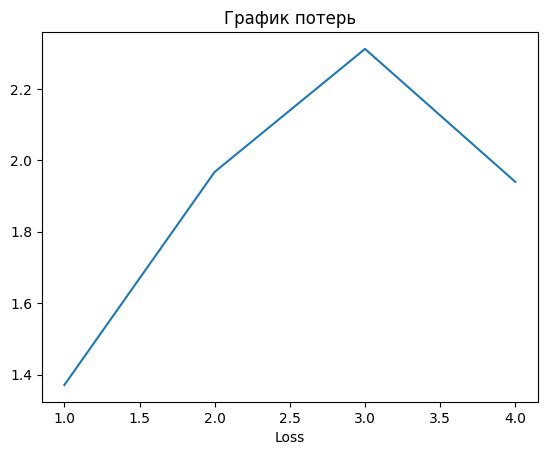

In [36]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(np.arange(1, n_epochs+1), losses)
plt.title('График потерь')
plt.xlabel('Epoch')
plt.xlabel('Loss')

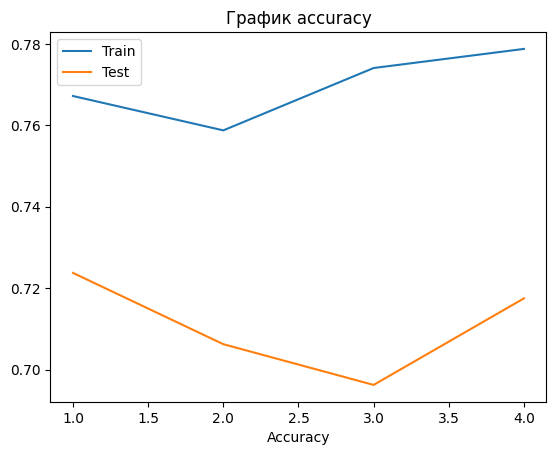

In [38]:
plt.plot(np.arange(1, n_epochs+1), acc_train, label = 'Train')
plt.plot(np.arange(1, n_epochs+1), acc_test, label = 'Test')
plt.title('График accuracy')
plt.xlabel('Epoch')
plt.xlabel('Accuracy')
plt.legend()

In [41]:
# итоговое значение метрик на тестовом и обучающем
train_true = []
train_pred = []
for x_train, y_train in train_loader:
    out = model(x_train.to(device))
    y_pred = th.argmax(out, dim = -1)
    train_true.extend(y_train.tolist())
    train_pred.extend(y_pred.tolist())

print(accuracy_score(y_true = train_true, y_pred = train_pred))

test_true = []
test_pred = []
for x_test, y_test in test_loader:
    out = model(x_test.to(device))
    y_pred = th.argmax(out,dim = -1)
    test_true.extend(y_test.tolist())
    test_pred.extend(y_pred.tolist())

print(accuracy_score(y_true = test_true, y_pred = test_pred))

0.779375
0.70625


In [ ]:
%time
import time

start_time = time.time()
import torch.optim as optim

n_epochs = 5
optimizer = optim.Adam(model.parameters(), lr = 0.001)
criterion = nn.CrossEntropyLoss()
model = model.to(device)
losses = []

acc_train_list = []
acc_test_list = []

for epoch in range(n_epochs):


  acc_train, acc_test = 0, 0

  for x_train, y_train in train_loader:

    out = model(x_train.to(device))
    loss = criterion(out, y_train.to(device))
    y_pred_train = th.argmax(out, dim=1)   #  предсказанный класс
    acc_train += th.sum(y_pred_train == y_train.to(device)).item()



    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
  losses.append(loss.item())
  print(f'Epoch {epoch+1}: loss {loss}')

  for x_test, y_test in test_loader:
    out = model(x_test.to(device))
    y_pred_test = th.argmax(out, dim = 1)
    acc_test += th.sum(y_pred_test == y_test.to(device)).item()

  acc_train_list.append(acc_train/len(train))
  acc_test_list.append(acc_test/len(test))
end_time = time.time()

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 6.91 µs
Epoch 1: loss 0.6247760057449341
Epoch 2: loss 0.5662394762039185
Epoch 3: loss 0.5135091543197632
Epoch 4: loss 0.5373188853263855
Epoch 5: loss 0.4634980261325836


In [ ]:
time1 = start_time - end_time

In [ ]:
losses

[0.6247760057449341,
 0.5662394762039185,
 0.5135091543197632,
 0.5373188853263855,
 0.4634980261325836]

Text(0, 0.5, 'Loss')

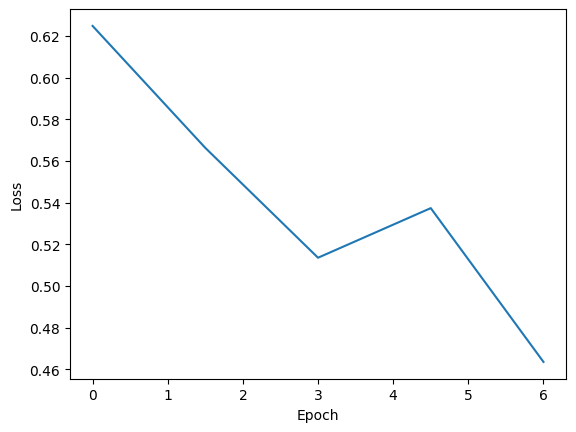

In [ ]:
import matplotlib.pyplot as plt

plt.plot(th.linspace(0, n_epochs+1, n_epochs).cpu().numpy(), losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')

In [ ]:
acc_train_list, acc_test_list

([0.7090625, 0.783125, 0.7984375, 0.8034375, 0.815],
 [0.76875, 0.7725, 0.765, 0.7575, 0.7825])

Text(0, 0.5, 'Значение accuracy')

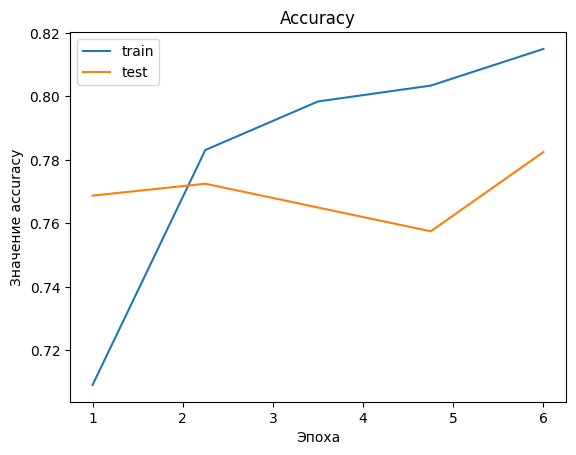

In [ ]:
plt.plot(th.linspace(1, n_epochs+1, n_epochs).cpu().numpy(), acc_train_list)
plt.plot(th.linspace(1, n_epochs+1, n_epochs).cpu().numpy(), acc_test_list)
plt.title('Accuracy')
plt.legend(['train', 'test'])
plt.xlabel('Эпоха')
plt.ylabel('Значение accuracy')

In [ ]:
# итоговое значение метрики accuracy на обучающем и тестовом множестве.

accuracy_train, accuracy_test = [], []

acc_train = 0
acc_test = 0
for x_train, y_train in train_loader:

  out = model(x_train.to(device))    # вероятность принадлежности к каждому классу
  y_pred_train = th.argmax(out, dim=1)   #  предсказанный класс
  acc_train += th.sum(y_pred_train == y_train.to(device)).item()


for x_test, y_test in test_loader:
  out = model(x_test.to(device))
  y_pred_test = th.argmax(out, dim = 1)
  acc_test += th.sum(y_pred_test == y_test.to(device)).item()


acc_train/len(train), (acc_test/len(test))

(0.825625, 0.77875)

<p class="task" id="4"></p>

4\. Повторите решение предыдущей задачи, заморозив все сверточные слои, кроме последнего (слои классификатора не замораживайте). Сравните качество полученного решения и решения из предыдущей задачи, а также время, затраченное на обучения моделей.

- [ ] Проверено на семинаре

In [ ]:
for name, param in model.named_parameters():
  # print(name)
  if 'features' in name:
  # print(param.requires_grad)
    param.requires_grad_(False)
  # print(param.requires_grad)


In [ ]:
for name, param in model.named_parameters():
  print(name, param.requires_grad)


features.0.weight False
features.0.bias False
features.2.weight False
features.2.bias False
features.5.weight False
features.5.bias False
features.7.weight False
features.7.bias False
features.10.weight False
features.10.bias False
features.12.weight False
features.12.bias False
features.14.weight False
features.14.bias False
features.17.weight False
features.17.bias False
features.19.weight False
features.19.bias False
features.21.weight False
features.21.bias False
features.24.weight False
features.24.bias False
features.26.weight False
features.26.bias False
features.28.weight False
features.28.bias False
classifier.0.weight False
classifier.0.bias True
classifier.3.weight False
classifier.3.bias True
classifier.6.weight True
classifier.6.bias True


In [ ]:
%time
start_time = time.time()
import torch.optim as optim

n_epochs = 5
optimizer = optim.Adam(model.parameters(), lr = 0.001)
criterion = nn.CrossEntropyLoss()
model = model.to(device)
losses = []

acc_train_list = []
acc_test_list = []

for epoch in range(n_epochs):


  acc_train, acc_test = 0, 0

  for x_train, y_train in train_loader:

    out = model(x_train.to(device))
    loss = criterion(out, y_train.to(device))
    y_pred_train = th.argmax(out, dim=1)   #  предсказанный класс
    acc_train += th.sum(y_pred_train == y_train.to(device)).item()


    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
  losses.append(loss.item())
  print(f'Epoch {epoch+1}: loss {loss}')

  for x_test, y_test in test_loader:
    out = model(x_test.to(device))
    y_pred_test = th.argmax(out, dim = 1)
    acc_test += th.sum(y_pred_test == y_test.to(device)).item()

  acc_train_list.append(acc_train/len(train))
  acc_test_list.append(acc_test/len(test))

end_time = time.time()

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 4.77 µs
Epoch 1: loss 0.5041956901550293
Epoch 2: loss 0.5175020098686218
Epoch 3: loss 0.5732406973838806
Epoch 4: loss 0.45204225182533264
Epoch 5: loss 0.43242043256759644


In [ ]:
time2 = start_time - end_time
abs(time1), abs(time2)
# время почти одинаковое

(196.15151262283325, 195.4023199081421)

In [ ]:
losses

[0.5041956901550293,
 0.5175020098686218,
 0.5732406973838806,
 0.45204225182533264,
 0.43242043256759644]

Text(0, 0.5, 'Loss')

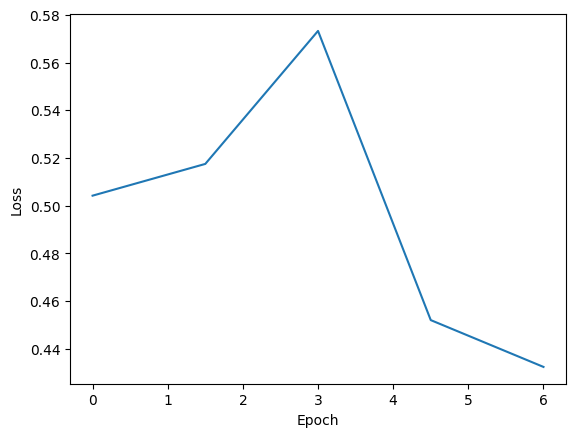

In [ ]:
import matplotlib.pyplot as plt

plt.plot(th.linspace(0, n_epochs+1, n_epochs).cpu().numpy(), losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')

In [ ]:
acc_train_list, acc_test_list

([0.811875, 0.813125, 0.815625, 0.8265625, 0.829375],
 [0.76375, 0.785, 0.775, 0.78375, 0.7675])

Text(0, 0.5, 'Значение accuracy')

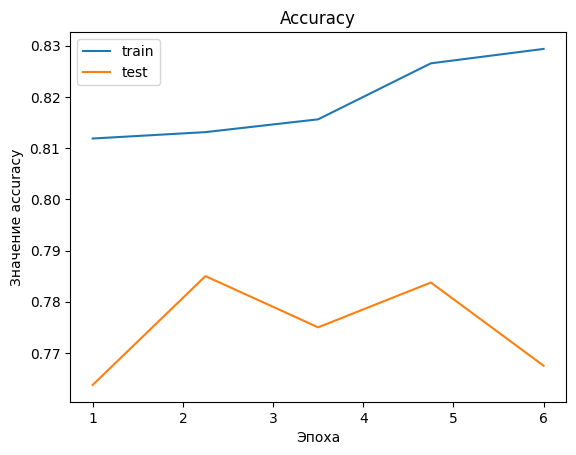

In [ ]:
plt.plot(th.linspace(1, n_epochs+1, n_epochs).cpu().numpy(), acc_train_list)
plt.plot(th.linspace(1, n_epochs+1, n_epochs).cpu().numpy(), acc_test_list)
plt.title('Accuracy')
plt.legend(['train', 'test'])
plt.xlabel('Эпоха')
plt.ylabel('Значение accuracy')

In [ ]:
# итоговое значение метрики accuracy на обучающем и тестовом множестве.

accuracy_train, accuracy_test = [], []

acc_train = 0
acc_test = 0
for x_train, y_train in train_loader:

  out = model(x_train.to(device))    # вероятность принадлежности к каждому классу
  y_pred_train = th.argmax(out, dim=1)   #  предсказанный класс
  acc_train += th.sum(y_pred_train == y_train.to(device)).item()


for x_test, y_test in test_loader:
  out = model(x_test.to(device))
  y_pred_test = th.argmax(out, dim = 1)
  acc_test += th.sum(y_pred_test == y_test.to(device)).item()


acc_train/len(train), (acc_test/len(test))

(0.835625, 0.7475)

<p class="task" id="5"></p>

5\. Повторите решение задачи, расширив обучающий набор данных при помощи преобразований из `torchvision`, изменяющих изображение (повороты, изменение интенсивности пикселей, обрезание и т.д.). При оценке модели на тестовой выборке данные преобразования применяться не должны. Решение о том, сколько и каких слоев модели будет обучаться, примите самостоятельно.

- [ ] Проверено на семинаре

In [ ]:
from torchvision import datasets

CatBreeds = datasets.ImageFolder("cat_breeds_4")
CatBreeds

Dataset ImageFolder
    Number of datapoints: 4000
    Root location: cat_breeds_4

In [ ]:
from torch.utils.data import Dataset, DataLoader, random_split


train, test = random_split(
    CatBreeds,
     [0.8, 0.2]
)

In [ ]:
train.dataset.transform

In [ ]:
train_transforms = T.Compose([
    T.Resize((256,256)),
    transforms.CenterCrop((224, 224)),
    T.RandomHorizontalFlip(p = 1),
    T.RandomVerticalFlip(p = 1),
    T.RandomRotation(50),   # угол поворота
    # T.ToPILImage(mode="RGB"),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.5, 0.406), std=(0.229, 0.3, 0.225))

])

test_transforms = T.Compose(
    [
        models.VGG16_Weights.IMAGENET1K_V1.transforms()
    ]
)

train_transforms, test_transforms

/usr/local/lib/python3.10/dist-packages/torchvision/transforms/v2/_deprecated.py:43: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.
  warnings.warn(


(Compose(
       Resize(size=[256, 256], interpolation=InterpolationMode.BILINEAR, antialias=warn)
       CenterCrop(size=(224, 224))
       RandomHorizontalFlip(p=1)
       RandomVerticalFlip(p=1)
       RandomRotation(degrees=[-50.0, 50.0], interpolation=InterpolationMode.NEAREST, expand=False, fill=0)
       ToTensor()
       Normalize(mean=[0.485, 0.5, 0.406], std=[0.229, 0.3, 0.225], inplace=False)
 ),
 Compose(
       ImageClassification(
       crop_size=[224]
       resize_size=[256]
       mean=[0.485, 0.456, 0.406]
       std=[0.229, 0.224, 0.225]
       interpolation=InterpolationMode.BILINEAR
   )
 ))

In [ ]:
train.dataset.transform = train_transforms
test.dataset.transform = test_transforms
# train.dataset.transform

In [ ]:
# plt.imshow(train[10][0][2])

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_loader = DataLoader(train, batch_size = 64)
test_loader = DataLoader(test, batch_size = 64)

In [ ]:
%time
start_time = time.time()
import torch.optim as optim

n_epochs = 5
optimizer = optim.Adam(model.parameters(), lr = 0.001)
criterion = nn.CrossEntropyLoss()
model = model.to(device)
losses = []

acc_train_list = []
acc_test_list = []

for epoch in range(n_epochs):


  acc_train, acc_test = 0, 0

  for x_train, y_train in train_loader:

    out = model(x_train.to(device))
    loss = criterion(out, y_train.to(device))
    y_pred_train = th.argmax(out, dim=1)   #  предсказанный класс
    acc_train += th.sum(y_pred_train == y_train.to(device)).item()


    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
  losses.append(loss.item())
  print(f'Epoch {epoch+1}: loss {loss}')

  for x_test, y_test in test_loader:
    out = model(x_test.to(device))
    y_pred_test = th.argmax(out, dim = 1)
    acc_test += th.sum(y_pred_test == y_test.to(device)).item()

  acc_train_list.append(acc_train/len(train))
  acc_test_list.append(acc_test/len(test))

end_time = time.time()

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 7.15 µs
Epoch 1: loss 0.5384523868560791
Epoch 2: loss 0.4510617256164551
Epoch 3: loss 0.42309901118278503
Epoch 4: loss 0.29702454805374146
Epoch 5: loss 0.44286903738975525


In [ ]:
time3 = start_time - end_time
abs(time3)

194.23489713668823

In [ ]:
losses

[0.5384523868560791,
 0.4510617256164551,
 0.42309901118278503,
 0.29702454805374146,
 0.44286903738975525]

Text(0, 0.5, 'Loss')

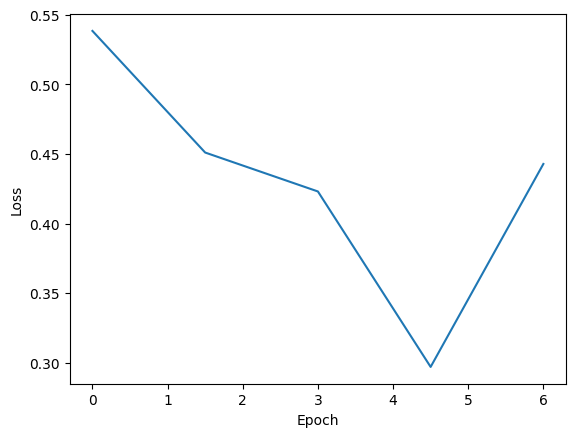

In [ ]:
import matplotlib.pyplot as plt

plt.plot(th.linspace(0, n_epochs+1, n_epochs).cpu().numpy(), losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')

In [ ]:
acc_train_list, acc_test_list

([0.8090625, 0.8234375, 0.8290625, 0.8221875, 0.825],
 [0.81125, 0.8075, 0.79125, 0.8, 0.78375])

Text(0, 0.5, 'Значение accuracy')

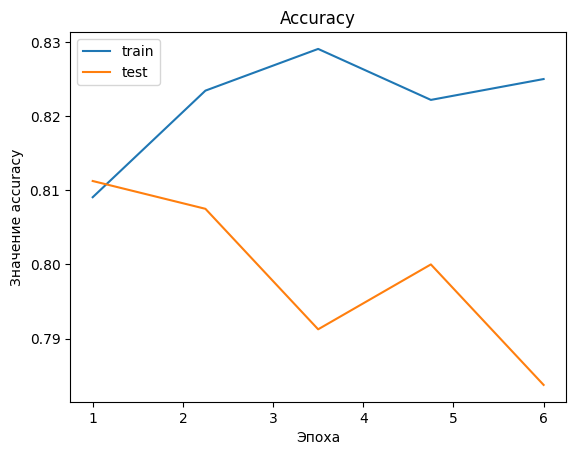

In [ ]:
plt.plot(th.linspace(1, n_epochs+1, n_epochs).cpu().numpy(), acc_train_list)
plt.plot(th.linspace(1, n_epochs+1, n_epochs).cpu().numpy(), acc_test_list)
plt.title('Accuracy')
plt.legend(['train', 'test'])
plt.xlabel('Эпоха')
plt.ylabel('Значение accuracy')

In [ ]:
# итоговое значение метрики accuracy на обучающем и тестовом множестве.

accuracy_train, accuracy_test = [], []

acc_train = 0
acc_test = 0
for x_train, y_train in train_loader:

  out = model(x_train.to(device))    # вероятность принадлежности к каждому классу
  y_pred_train = th.argmax(out, dim=1)   #  предсказанный класс
  acc_train += th.sum(y_pred_train == y_train.to(device)).item()


for x_test, y_test in test_loader:
  out = model(x_test.to(device))
  y_pred_test = th.argmax(out, dim = 1)
  acc_test += th.sum(y_pred_test == y_test.to(device)).item()


acc_train/len(train), (acc_test/len(test))

(0.84375, 0.78625)

## Обратная связь
- [x] Хочу получить обратную связь по решению